In [1]:
# 임의의 데이터로 PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.RandomState(13)
x = rng.randn(2, 200)

x.shape

(2, 200)

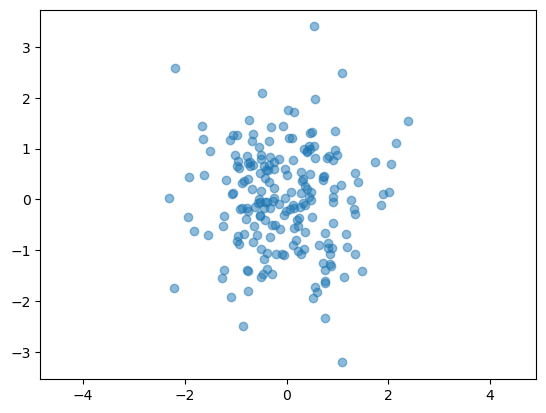

In [2]:
plt.scatter(x[0, :], x[1, :], alpha=0.5)
plt.axis('equal')
plt.show()

In [4]:
p1 = np.array([[2, 1], [1, 3]])

x = np.dot(p1, x).T
x.shape

(200, 2)

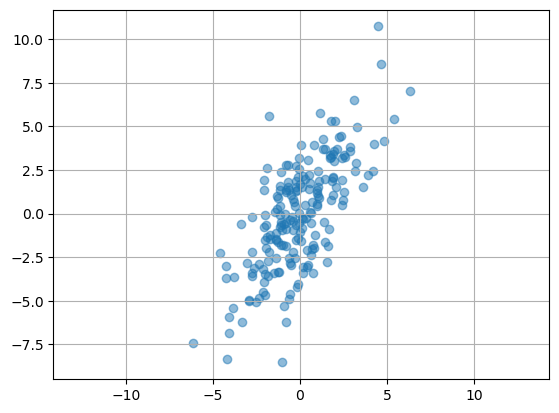

In [5]:
plt.scatter(x[:, 0], x[:, 1], alpha=0.5)

plt.grid()
plt.axis('equal')
plt.show()

In [6]:
# PCA
from sklearn.decomposition import PCA

# 주성분 2개로 축소
pca = PCA(n_components=2, random_state=13)
pca.fit(x)

PCA(n_components=2, random_state=13)

In [ ]:
# 축소된 벡터
pca.components_

array([[ 0.47835022,  0.87816916],
       [ 0.87816916, -0.47835022]])

In [8]:
# 벡터의 설명력
pca.explained_variance_

array([12.17995044,  1.61157848])

In [9]:
# 벡터 시각화하는 함수
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops = dict(arrowstyle='->',
                      linewidth=2,
                      color='black',
                      shrinkA=0,
                      shrinkB=0)
    ax.annotate('', v1, v0, arrowprops=arrowprops)

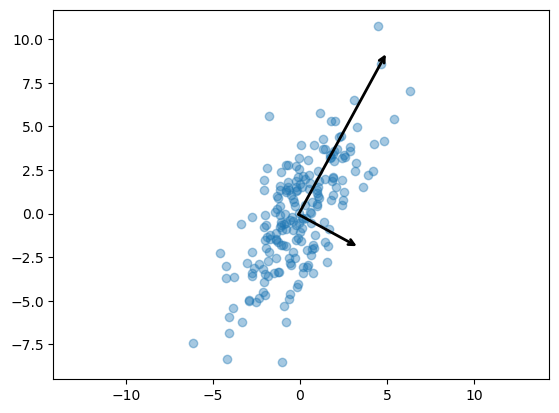

In [10]:
# 벡터 시각화
plt.scatter(x[:, 0], x[:, 1], alpha=0.4)

for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)

plt.axis('equal')
plt.show()

In [12]:
# 주성분 1개로 축소
pca = PCA(n_components=1, random_state=13)
pca.fit(x)
x_pca = pca.transform(x)

pca.explained_variance_ratio_

array([0.88314722])

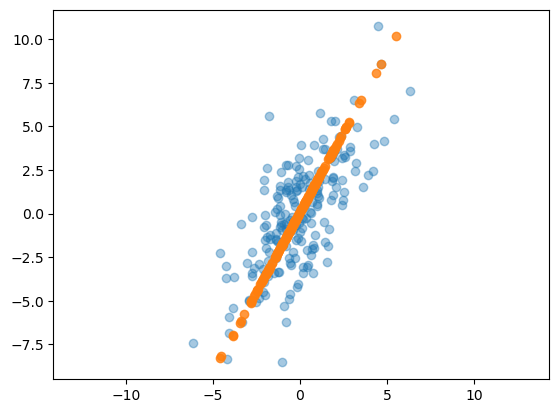

In [ ]:
# 변환된 데이터 시각화
x_new = pca.inverse_transform(x_pca)

plt.scatter(x[:, 0], x[:, 1], alpha=0.4)
plt.scatter(x_new[:, 0], x_new[:, 1], alpha=0.8)

plt.axis('equal')
plt.show()

In [14]:
# iris 데이터에 적용
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [15]:
# 정규화
from sklearn.preprocessing import StandardScaler

iris_ss = StandardScaler().fit_transform(iris.data)

In [16]:
# 차원 축소하는 함수
def get_pca_data(ss_data, n_components=2):
    pca = PCA(n_components=n_components)
    pca.fit(ss_data)

    return pca.transform(ss_data), pca

In [18]:
# 4개의 feature가 2개로 축소
iris_pca, pca = get_pca_data(iris_ss, 2)
iris_ss.shape, iris_pca.shape

((150, 4), (150, 2))

In [19]:
# 주성분 DataFrame으로 만드는 함수
def get_df_from_pca(pca_data, cols=['PC1', 'PC2']):
    return pd.DataFrame(pca_data, columns=cols)

In [20]:
iris_df_pca = get_df_from_pca(iris_pca)
iris_df_pca['species'] = iris.target
iris_df_pca.head()

,PC1,PC2,species
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


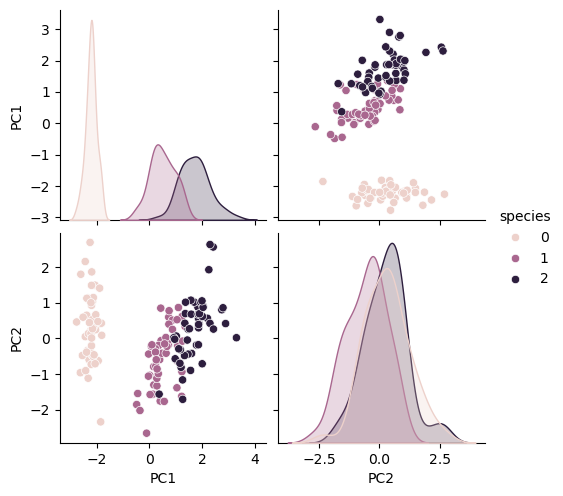

In [21]:
sns.pairplot(iris_df_pca, hue='species')
plt.show()

In [22]:
# 설명력 출력해주는 함수
def print_variance_ratio(pca):
    print('Explained variance ratio: {}'.format(pca.explained_variance_ratio_)) 
    print('Cumulative explained variance ratio: {}'.format(np.cumsum(pca.explained_variance_ratio_))) 

In [23]:
print_variance_ratio(pca)

Explained variance ratio: [0.72962445 0.22850762]
Cumulative explained variance ratio: [0.72962445 0.95813207]


In [24]:
# Model 학습
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def rfc_scores(x, y, cv=5):
    rfc = RandomForestClassifier(n_estimators=100, random_state=13)
    scores = cross_val_score(rfc, x, y, scoring='accuracy', cv=cv)
    print('CV accuracy scores: {}'.format(scores))

In [25]:
rfc_scores(iris_ss, iris.target)

pca_x = iris_df_pca[['PC1', 'PC2']]
rfc_scores(pca_x, iris.target)

CV accuracy scores: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
CV accuracy scores: [0.86666667 0.93333333 0.83333333 0.9        1.        ]


In [26]:
# wine 데이터 적용
wine_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial/master/dataset/wine.csv' 
wine = pd.read_csv(wine_url, sep=',', index_col=0) 
wine.head() 

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [27]:
x = wine.drop('color', axis=1)
y = wine['color']

In [ ]:
# 12개 feature 2개로 축소
wine_ss = StandardScaler().fit_transform(x)

pca_wine, pca = get_pca_data(wine_ss, 2)
wine_ss.shape, pca_wine.shape

((6497, 12), (6497, 2))

In [29]:
print_variance_ratio(pca)

Explained variance ratio: [0.25346226 0.22082117]
Cumulative explained variance ratio: [0.25346226 0.47428343]


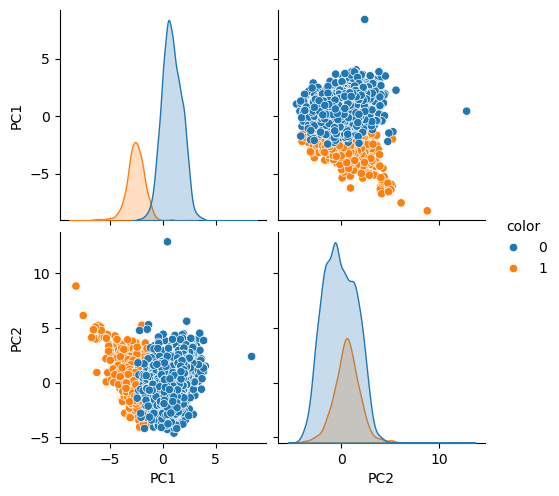

In [30]:
pca_columns = ['PC1', 'PC2']
pca_wine_df = get_df_from_pca(pca_wine, pca_columns)
pca_wine_df['color'] = y.values

sns.pairplot(pca_wine_df, hue='color')
plt.show()

In [31]:
rfc_scores(wine_ss, y)

pca_x = pca_wine_df[pca_columns]
rfc_scores(pca_x, y)

CV accuracy scores: [0.99230769 0.99615385 0.99538106 0.98691301 0.99692071]
CV accuracy scores: [0.98307692 0.98153846 0.98845266 0.97228637 0.9799846 ]


In [32]:
# 3개로 소
pca_wine, pca = get_pca_data(wine_ss, 3)
print_variance_ratio(pca)

Explained variance ratio: [0.25346226 0.22082117 0.13679223]
Cumulative explained variance ratio: [0.25346226 0.47428343 0.61107566]


In [33]:
cols = ['PC1', 'PC2', 'PC3']
pca_wine_df = get_df_from_pca(pca_wine, cols)
pca_wine_df.head()

,PC1,PC2,PC3
0,-3.348438,0.568926,-2.727386
1,-3.228595,1.197335,-1.998904
2,-3.237468,0.952580,-1.746578
3,-1.672561,1.600583,2.856552
4,-3.348438,0.568926,-2.727386


In [34]:
pca_x = pca_wine_df[cols]
rfc_scores(pca_x, y)

CV accuracy scores: [0.98307692 0.97923077 0.9899923  0.97767513 0.98614319]


In [ ]:
# 3개 주성분 시각화
# 어느정도 구분되는 것으로 볼 수 있음
import plotly.express as px

pca_wine_plot = pca_x
pca_wine_plot['color'] = y.values

fig = px.scatter_3d(pca_wine_plot,
                    x='PC1',
                    y='PC2',
                    z='PC3',
                    color='color')

fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.show()